## RANDOM FOREST

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree

In [2]:
df=pd.read_excel('glass.xlsx',sheet_name=1)

In [3]:
df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [4]:
df.shape

(214, 10)

### 1. Exploratory Data Analysis (EDA):

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


In [6]:
## missing value
df.isnull().sum()

RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

In [7]:
## duplicates
df.duplicated().sum()

np.int64(1)

In [8]:
df.drop_duplicates(inplace=True,ignore_index=True)
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
count,213.000000,213.000000,213.000000,213.000000,213.000000,213.000000,213.000000,213.000000,213.000000,213.000000
mean,1.518348,13.404085,2.679202,1.449484,72.655070,0.498873,8.954085,0.175869,0.057277,2.788732
std,0.003033,0.816662,1.443691,0.495925,0.773998,0.653185,1.425882,0.498245,0.097589,2.105130
min,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000,1.000000
25%,1.516520,12.900000,2.090000,1.190000,72.280000,0.130000,8.240000,0.000000,0.000000,1.000000
50%,1.517680,13.300000,3.480000,1.360000,72.790000,0.560000,8.600000,0.000000,0.000000,2.000000
75%,1.519150,13.810000,3.600000,1.630000,73.090000,0.610000,9.150000,0.000000,0.100000,3.000000
max,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000,7.000000


In [10]:
## mixed data format
mixed_formats = df.applymap(lambda x: isinstance(x, str)).sum()
print(mixed_formats)

RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64


In [11]:
## unique values
print(df['Type'].unique())

[1 2 3 5 6 7]


In [12]:
##  imbalance
df['Type'].value_counts()

Type
2    76
1    69
7    29
3    17
5    13
6     9
Name: count, dtype: int64

In [13]:
target=df['Type']
features=df.drop(columns=['Type'])

<Axes: >

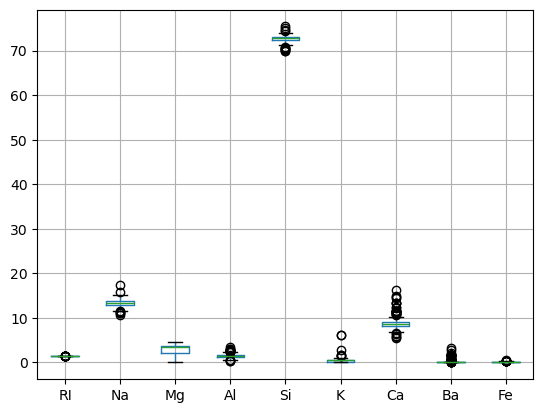

In [14]:
## outlier
features.boxplot()

In [15]:
##outlier capping
def outlier_capping(df,column):
    Q1=df[column].quantile(0.25)
    Q3=df[column].quantile(0.75)
    IQR=Q3-Q1
    Lower_Extreme= Q1-1.5*IQR
    Upper_Extreme= Q3+1.5*IQR
    df[column]= df[column].apply(lambda x: Lower_Extreme if x<Lower_Extreme else Upper_Extreme if x>Upper_Extreme else x)
for col in features.select_dtypes(['int','float']).columns:
    outlier_capping(features,col)

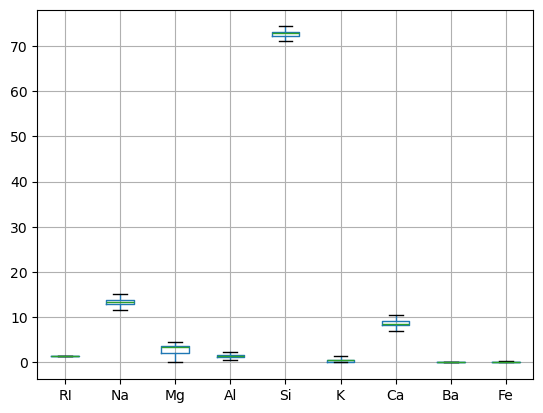

In [16]:
## outlier
features.boxplot()
plt.show()

### 2: Data Visualization:

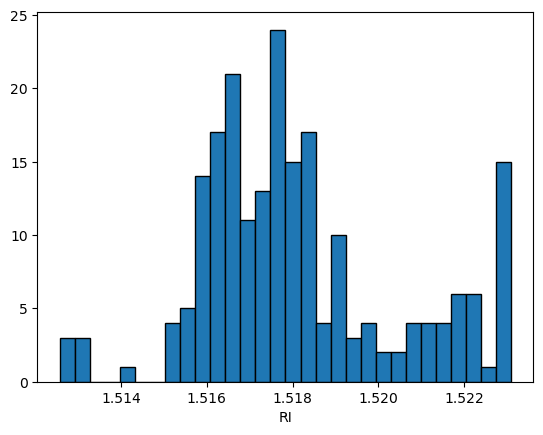

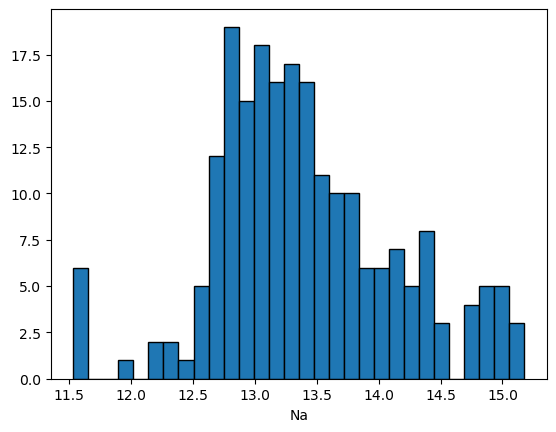

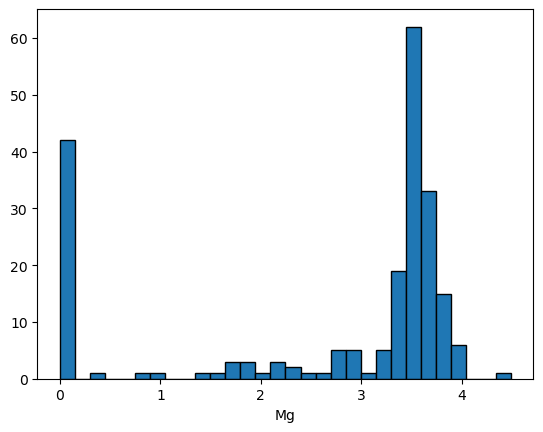

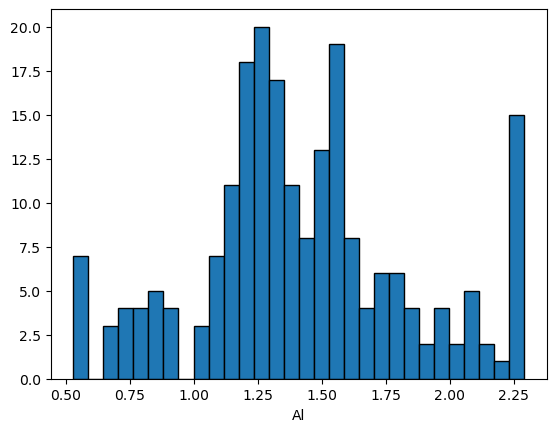

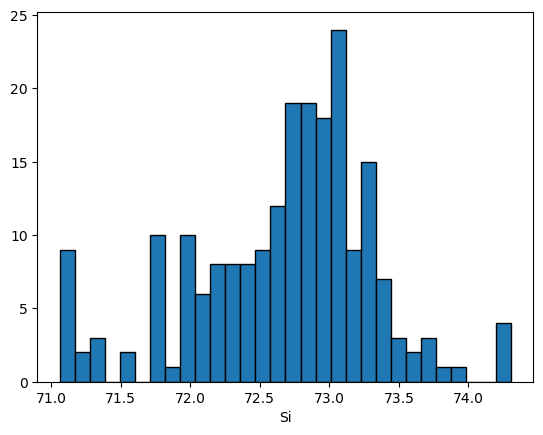

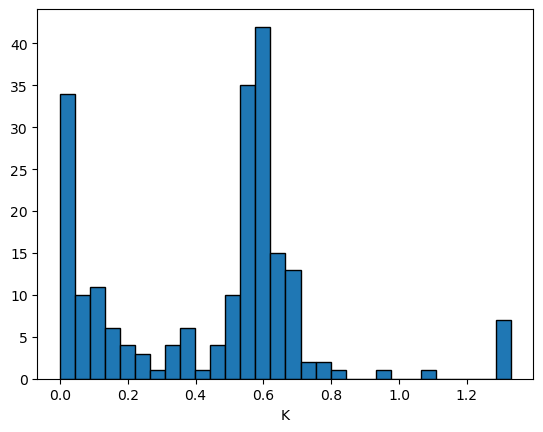

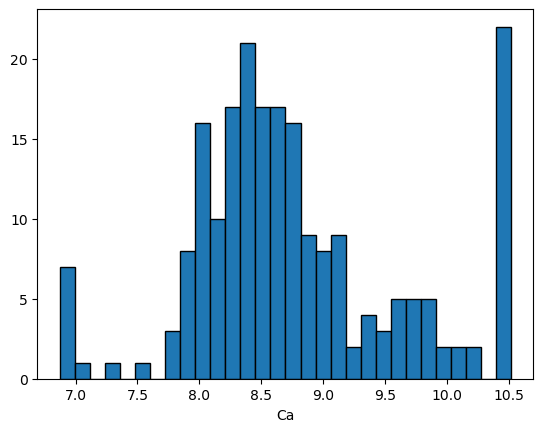

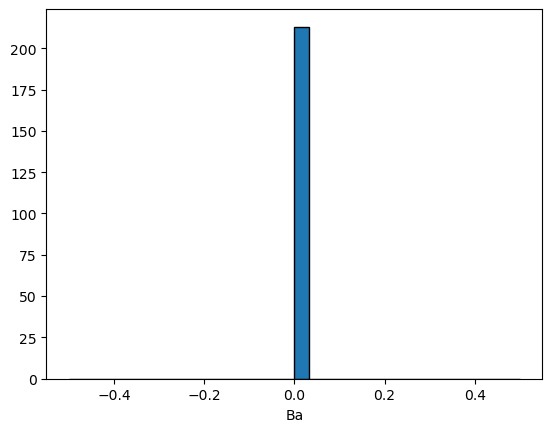

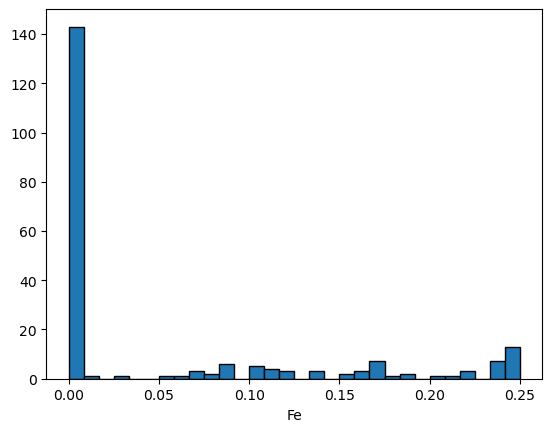

In [17]:
## histogram
for col in features:
    plt.hist(features[col], bins=30, edgecolor='black')
    plt.xlabel(col)
    plt.show()

In [18]:
## drop ba
features.drop(columns=['Ba'],inplace=True)

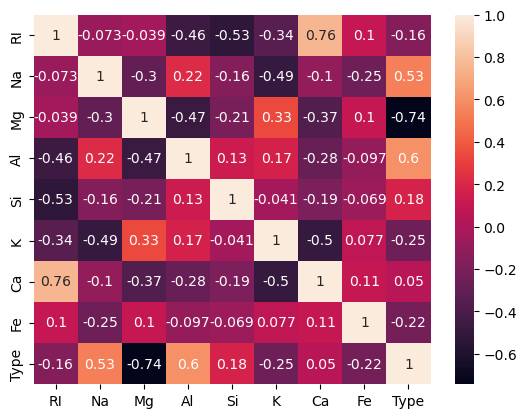

In [19]:
## correlation
df1 = features.copy()
df1["Type"] = target 
corr = df1.corr()
sns.heatmap(corr,annot=True)
plt.show()

### 3: Data Preprocessing

In [20]:
x_train,x_test,y_train,y_test=train_test_split(features,target,test_size=0.3,random_state=100,stratify=target)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(149, 8)
(64, 8)
(149,)
(64,)


In [21]:
std_sca=StandardScaler()
x_train=pd.DataFrame(std_sca.fit_transform(x_train),columns=features.columns)
x_test=pd.DataFrame(std_sca.fit_transform(x_test),columns=features.columns)

In [22]:
x_train

,RI,Na,Mg,Al,Si,K,Ca,Fe
0,-0.260109,-1.623776,0.381793,-0.586261,1.244913,0.497934,0.192535,2.256473
1,-0.836006,-0.094293,0.575711,-0.160380,-0.040943,0.312685,-0.464302,-0.598852
2,-0.779715,1.083274,-1.869040,2.087324,1.113405,-1.292806,0.353863,0.471895
3,1.147160,0.203483,-0.421581,0.620401,-0.756931,0.220061,0.964606,1.423670
4,-0.597853,-0.351462,0.520306,0.833342,-0.318571,0.436185,-0.406685,1.423670
...,...,...,...,...,...,...,...,...
144,-0.225468,-0.798126,0.603414,-0.136720,0.470477,0.497934,-0.164693,-0.598852
145,0.185887,0.013989,0.825034,-0.184040,-0.464691,0.158311,-0.521920,-0.598852
146,1.506554,-2.523870,-0.684755,0.360141,1.084181,0.374435,2.053573,-0.598852
147,0.125266,-0.094293,0.444124,0.312821,-0.815379,0.312685,0.296246,-0.598852


### 4: Random Forest Model Implementation

In [23]:
rand_for=RandomForestClassifier(n_estimators=100,bootstrap=True,random_state=50,max_features='sqrt',max_samples=0.9,)
rand_for.fit(x_train,y_train)
y_pred=rand_for.predict(x_test)
y_pred_prob = rand_for.predict_proba(x_test)
accuracy_score(y_test,y_pred)

0.796875

In [24]:
precision = precision_score(y_test, y_pred,zero_division=0, average='macro')  
recall    = recall_score(y_test, y_pred,zero_division=0, average='macro')
f1        = f1_score(y_test, y_pred,zero_division=0, average='macro')
roc_auc = roc_auc_score(y_test, y_pred_prob,multi_class='ovo')
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)
print("ROC-AUC  :", roc_auc)

Precision: 0.8681644026471612
Recall   : 0.6848458707154359
F1-Score : 0.6865685689899097
ROC-AUC  : 0.9534623495130742


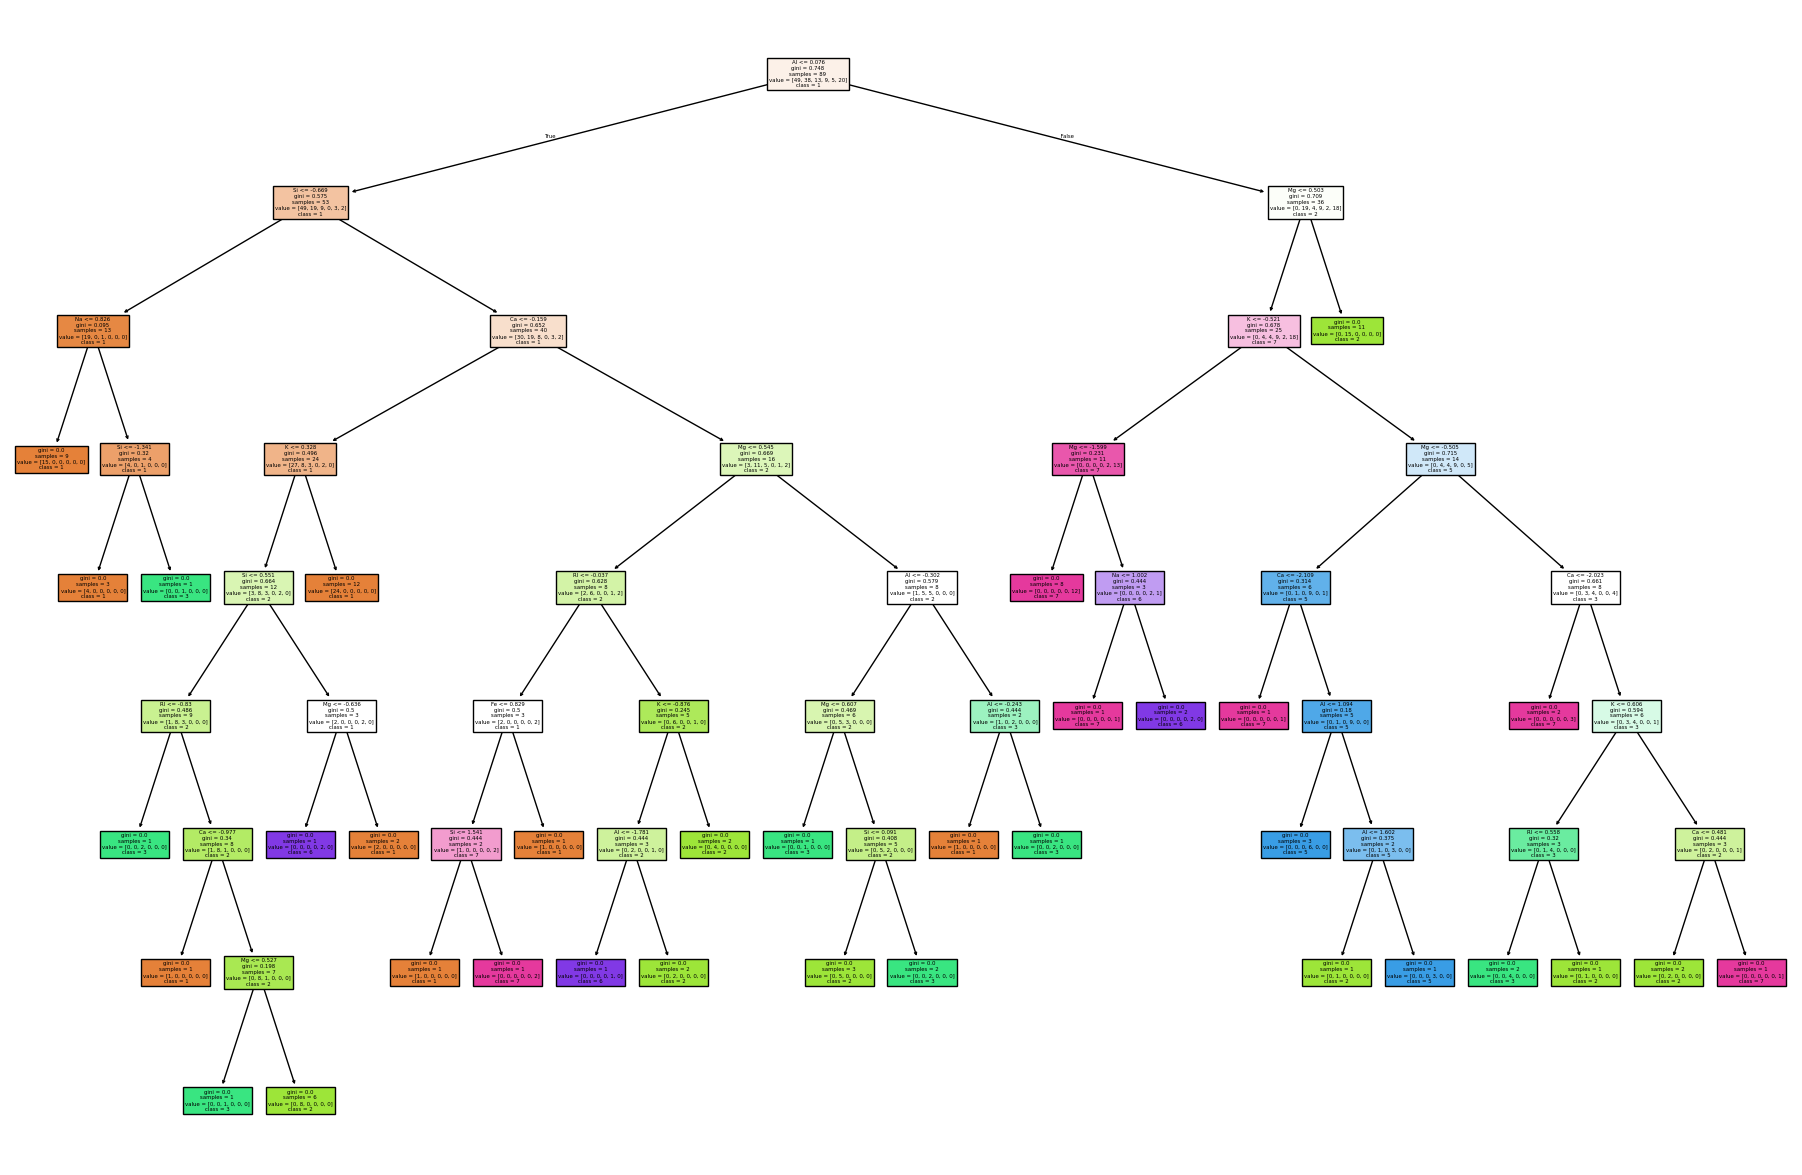

In [25]:
###  plotting RandomForest
plt.figure(figsize=(23,15))
plot_tree(rand_for.estimators_[10],filled=True,feature_names=list(features),class_names=[str(c) for c in sorted(df["Type"].unique())])
plt.show()

### 5: Bagging and Boosting Methods

In [40]:
from sklearn.ensemble import BaggingClassifier,AdaBoostClassifier,GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

##### Bagging

In [55]:
## using gridsearch
params={'n_estimators':[50,100,150,200]}
grid_search=GridSearchCV(bag_class,params,cv=5)
grid_search.fit(x_train,y_train)
grid_search.best_params_

{'n_estimators': 200}

In [56]:
bag_class=BaggingClassifier(estimator=DecisionTreeClassifier(),n_estimators=200,bootstrap=True,random_state=50,
                           bootstrap_features=True)
bag_class.fit(x_train,y_train)
y_pred=bag_class.predict(x_test)
accuracy_score(y_test,y_pred)

0.796875

##### Boosting

In [57]:
## AdaBoost

In [60]:
ada_boost=AdaBoostClassifier(estimator=DecisionTreeClassifier(),n_estimators=50,random_state=50)
ada_boost.fit(x_train,y_train)
y_pred=ada_boost.predict(x_test)
accuracy_score(y_test,y_pred)

0.75

In [52]:
### using gridsearch
params={'n_estimators':[50,100,150,200]}

In [53]:
grid_search=GridSearchCV(ada_boost,params,cv=5)
grid_search.fit(x_train,y_train)
grid_search.best_params_

{'n_estimators': 50}

In [58]:
### GradientBoostingClassifier

In [59]:
grad_boost=GradientBoostingClassifier(learning_rate=0.2, n_estimators=100,subsample=1,max_features=1)
grad_boost.fit(x_train,y_train)
y_pred=grad_boost.predict(x_test)
accuracy_score(y_test,y_pred)

0.796875

In [61]:
grid_search=GridSearchCV(grad_boost,params,cv=5)
grid_search.fit(x_train,y_train)
grid_search.best_params_

{'n_estimators': 100}

In [62]:
## XGBoost

In [74]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

In [75]:
lab_enc = LabelEncoder()
y_train_xgb = lab_enc.fit_transform(y_train)
y_test_xgb  = lab_enc.transform(y_test)

In [77]:
xgb=XGBClassifier(learning_rate=0.3,Reg_alpha=10,reg_lambda=15,min_child_weight=2,n_estimators=100)
xgb.fit(x_train,y_train_xgb )
y_pred=xgb.predict(x_test)
accuracy_score(y_test_xgb,y_pred)

0.796875

In [78]:
## Lightgbm

In [91]:
from lightgbm import LGBMClassifier

In [111]:
lgb = LGBMClassifier(learning_rate=0.3,reg_alpha=10,reg_lambda=15,min_child_weight=2,n_estimators=100,subsample=1.0, boosting_type='goss',          
     max_bin=100,top_rate=0.2,other_rate=0.3,random_state=42)

In [112]:
lgb.fit(x_train,y_train)
y_pred=lgb.predict(x_test)
accuracy_score(y_test,y_pred)

[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000079 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 301
[LightGBM] [Info] Number of data points in the train set: 149, number of used features: 8
[LightGBM] [Info] Using GOSS
[LightGBM] [Info] Start training from score -1.132745
[LightGBM] [Info] Start training from score -1.033654
[LightGBM] [Info] Start training from score -2.519040
[LightGBM] [Info] Start training from score -2.806722
[LightGBM] [Info] Start training from score 

0.703125

#### 1. Explain Bagging and Boosting methods. How is it different from each other.

#### 2. Explain how to handle imbalance in the data.